# **Mod_4 Assignment 1**

In [1]:
# Task 1 - Step 1
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
df = pd.read_csv(f'{path}/Sample - Superstore.csv', encoding='latin1')
df.shape

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.


(9994, 21)

In [2]:
# Task 1 - Step 2
print(df.shape)
print(df.dtypes)
df.describe()

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [3]:
# Task 1 - Step 3 and 4
features = ['Quantity', 'Discount', 'Profit']
df[features].isnull().sum()

,0
Quantity,0
Discount,0
Profit,0


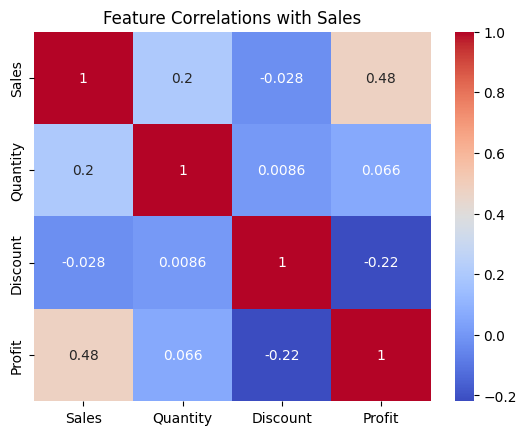

In [4]:
# Task 1 - Step 5
import seaborn as sns
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations with Sales')
plt.show()

In [5]:
# Task 2 - Step 1
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

In [6]:
# Task 2 - Step 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Task 2 - Step 3
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
# Task 2 - Step 4
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")

MSE: 680377.46, RMSE: 824.85, MAE: 245.08, R2: -0.1518


In [9]:
# Task 3 - Step 1
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Quantity: 41.5503
Discount: 249.5718
Profit: 1.5617
Intercept: -18.0971


In [10]:
# Task 4 - Step 1
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
# Task 4 - Step 2
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [12]:
# Task 4 - Step 3
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression'],
    'MSE': [mse, mse_poly],
    'RMSE': [rmse, rmse_poly],
    'MAE': [mae, mae_poly],
    'R2': [r2, r2_poly]
})
comparison

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,680377.456372,824.849960,245.075570,-0.151817
1,Polynomial Regression,473873.848924,688.384957,190.560721,0.197775


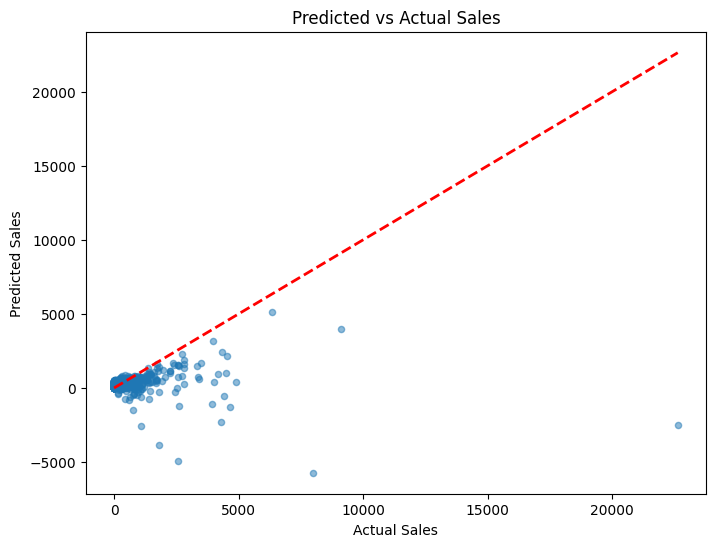

In [13]:
# Task 5 - Step 1
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')
plt.show()

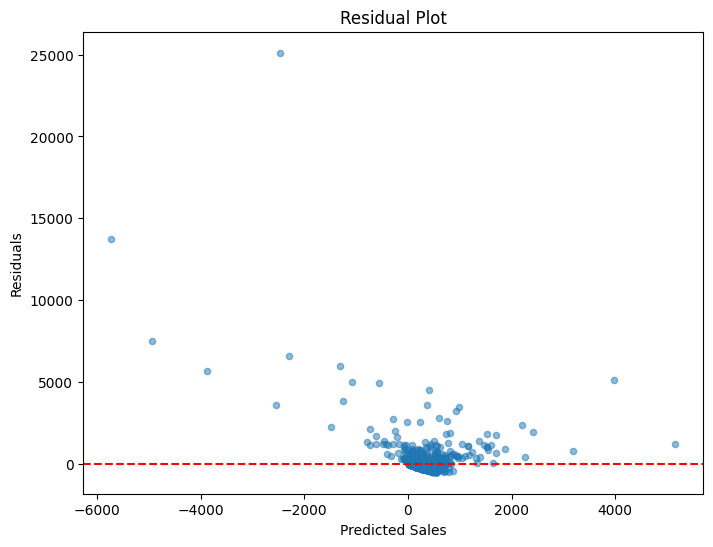

In [14]:
# Task 5 - Step 2
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# **Mod_4 Assignment 2**